(6000, 9000, 3)

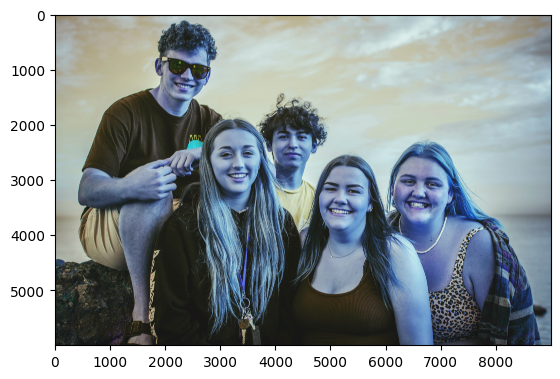

In [4]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
image = cv.imread('../assets/image1.jpg')

plt.imshow(image)
image.shape

In [8]:
my_kernel = np.ones((5,5), np.float32)/50
my_kernel

array([[0.02, 0.02, 0.02, 0.02, 0.02],
       [0.02, 0.02, 0.02, 0.02, 0.02],
       [0.02, 0.02, 0.02, 0.02, 0.02],
       [0.02, 0.02, 0.02, 0.02, 0.02],
       [0.02, 0.02, 0.02, 0.02, 0.02]], dtype=float32)

(([], []), ([], []))

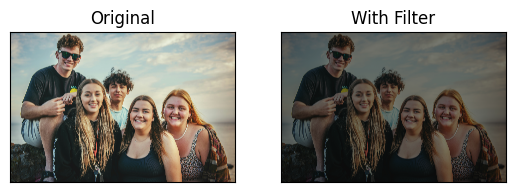

In [9]:
#Convert from bgr to rgb
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
#apply the kernel to the image
dst = cv.filter2D(image, -1, my_kernel)

#display the image using subplot
plt.subplot(121), plt.imshow(image), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(dst), plt.title('With Filter')
plt.xticks([]), plt.yticks([])

(([], []), ([], []))

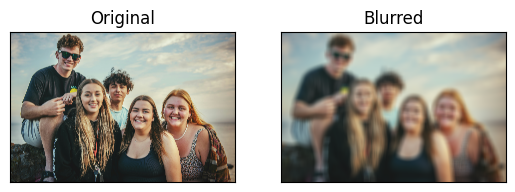

In [10]:
#BLURRING THE IMAGE

image = cv.imread("../assets/image1.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

blur = cv.blur(image, (250,250))
#display the image using subplot
plt.subplot(121), plt.imshow(image), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(blur), plt.title('Blurred')
plt.xticks([]), plt.yticks([])

(([], []), ([], []))

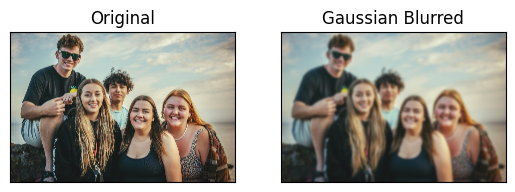

In [11]:
#guassian blurring

image = cv.imread("../assets/image1.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

blur = cv.GaussianBlur(image, (251,251), 0)
#display the image using subplot
plt.subplot(121), plt.imshow(image), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(blur), plt.title('Gaussian Blurred')
plt.xticks([]), plt.yticks([])

(([], []), ([], []))

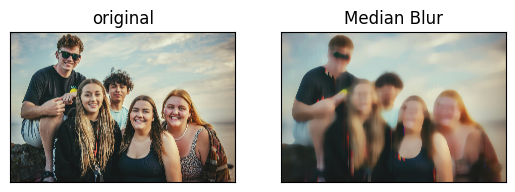

In [12]:
#Blurring is also called smoothing of an image
#Median Blur
image = cv.imread("../assets/image1.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

blurred = cv.medianBlur(image,341)

plt.subplot(121), plt.imshow(image), plt.title('original')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(blurred), plt.title('Median Blur')
plt.xticks([]), plt.yticks([])

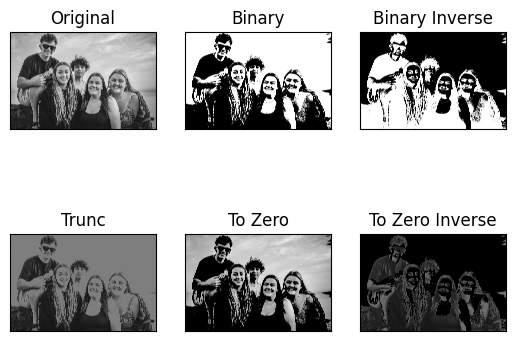

In [13]:
#Image Thresholding
#Load the imag as grayscale

image = cv.imread("../assets/image1.jpg", cv.IMREAD_GRAYSCALE)

ret, thresh1 = cv.threshold(image, 127, 255, cv.THRESH_BINARY) #Binary Thresholding
#Binary inverse thresholding
ret, thresh2 = cv.threshold(image, 127, 255, cv.THRESH_BINARY_INV)
#Trunc thresholding
ret, thresh3 = cv.threshold(image, 127, 255, cv.THRESH_TRUNC)
#To Zero THresholding
ret, thresh4 = cv.threshold(image, 127, 255, cv.THRESH_TOZERO)
#To Zero Inverse Thresholding
ret, thresh5 = cv.threshold(image, 127, 255, cv.THRESH_TOZERO_INV)

titles= ['Original', 'Binary', 'Binary Inverse', 'Trunc', 'To Zero', 'To Zero Inverse']
function_names = [image, thresh1, thresh2, thresh3, thresh4, thresh5]

#Display the images
for i in range(6):
  plt.subplot(2, 3, i+1), plt.imshow(function_names[i], 'gray', vmin = 0, vmax= 255)
  plt.title(titles[i])
  plt.xticks([]), plt.yticks([])

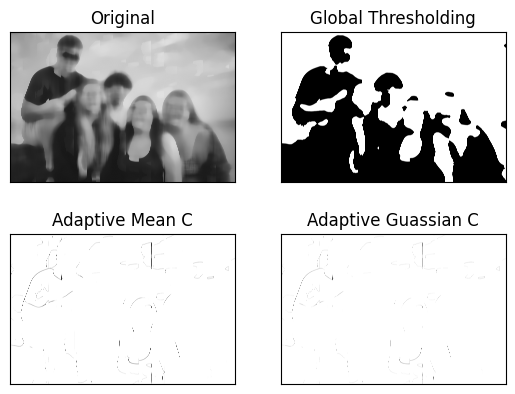

In [2]:
#Adaptive THresholding
image = cv.imread('../assets/image1.jpg', cv.IMREAD_GRAYSCALE)
image = cv.medianBlur(image, 341)
ret, thr1 = cv.threshold(image, 127, 255, cv.THRESH_BINARY)
thr2 = cv.adaptiveThreshold(image,255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 2 )
thr3 = cv.adaptiveThreshold(image, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)

titles = ['Original','Global Thresholding', "Adaptive Mean C", 'Adaptive Guassian C']
func = [image, thr1, thr2, thr3]

for i in range(4):
    plt.subplot(2,2,i+1), plt.imshow(func[i], 'gray', vmax= 255, vmin=0)
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
    




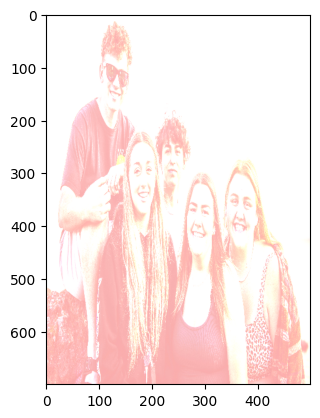

In [5]:
from PIL import Image
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

img = cv.imread('../assets/image1.jpg')

if img is not None:
    # 1. Get original dimensions
    h, w = img.shape[:2]
    dimension = (w, h)

    # 2. Create the solid color image (same size as original)
    img_purecolor = Image.new('RGB', dimension, (228, 150, 150))
    img_purecolor = np.array(img_purecolor)
    
    # 3. Convert RGB (PIL) to BGR (OpenCV) if you plan to keep using CV2
    img_purecolor = cv.cvtColor(img_purecolor, cv.COLOR_RGB2BGR)

    # 4. Perform the addition BEFORE resizing
    # Both are now (h, w, 3)
    img_new = cv.add(img_purecolor, img) 

    # 5. Resize the result for display
    img_display = cv.resize(img_new, (500, 700))
    
    # 6. Show it (Remember plt expects RGB, so convert back)
    plt.imshow(cv.cvtColor(img_display, cv.COLOR_BGR2RGB))
    plt.show()

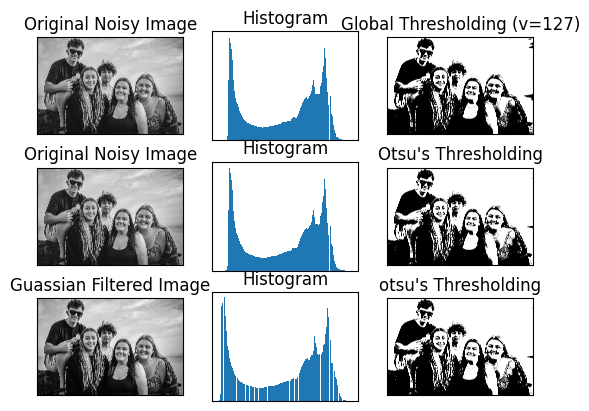

In [10]:
#otsu Thresholding
img = cv.imread("../assets/image1.jpg", cv.IMREAD_GRAYSCALE)

#Binary Thresholding
ret1,th1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
ret2, th2 =cv.threshold(img, 0, 255,cv.THRESH_BINARY+cv.THRESH_OTSU)

#otsu Thresholding after gaussian filtering
blur= cv.GaussianBlur(img, (5,5), 0)
ret3, th3 =cv.threshold(blur, 0, 255,cv.THRESH_BINARY+cv.THRESH_OTSU)

images = [img, 0, th1, img, 0, th2, blur, 0, th3]
titles = ["Original Noisy Image", "Histogram", "Global Thresholding (v=127)",
          "Original Noisy Image", "Histogram", "Otsu's Thresholding",
          "Guassian Filtered Image", "Histogram", "otsu's Thresholding"]

for i in range(3):
    plt.subplot(3,3,i*3+1), plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2), plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3), plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])

(500, 700, 3)

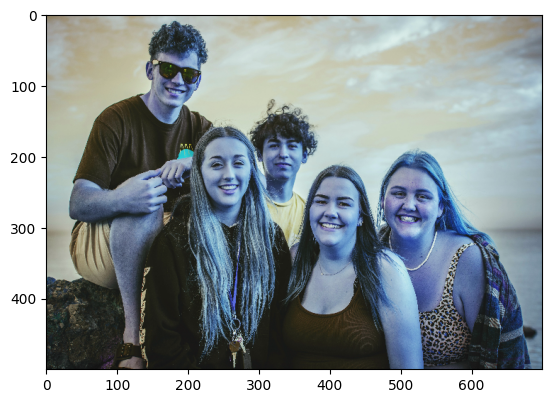

In [6]:
#Image Transformation/ Resizing
img = cv.imread('../assets/image1.jpg')

image_resized = cv.resize(img, (700, 500))
plt.imshow(image_resized)
image_resized.shape


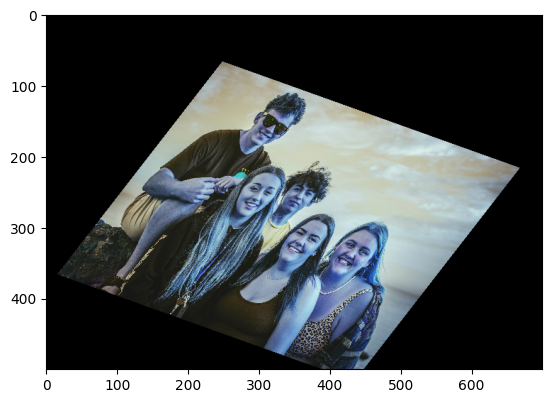

In [3]:
#image Translation with wrapping
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
img = cv.imread('../assets/image1.jpg')
rows, cols  = img.shape[:2]

pt1 = np.float32([[500,6000],[500, 1000], [8000, 6000]])
pt2 = np.float32([[500, 4500], [3000, 1500], [5000, 6000]])

M = cv.getAffineTransform(pt1, pt2)
dst = cv.warpAffine(img,M, (cols, rows))
dst = cv.resize(dst, (700, 500))

plt.imshow(dst)

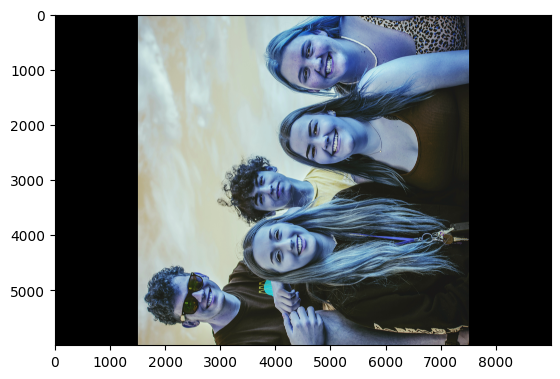

In [4]:
#image rotation
img = cv.imread('../assets/image1.jpg')
rows, cols = img.shape [:2]

M = cv.getRotationMatrix2D((cols/2, rows/2), 90, 1)
dst = cv.warpAffine(img, M, (cols, rows))

plt.imshow(dst)


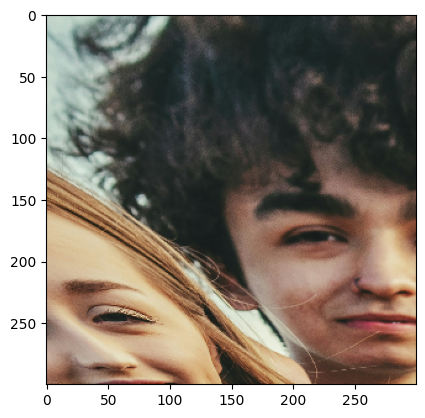

In [6]:
#perspective transform
import cv2 as cv
path = '../assets/image1.jpg'
img = cv.imread(path)
rows, cols = img.shape[:2]

pts1 = np.float32([[3800, 1800], [4400,1800], [3000, 2900], [4400, 2900]])
pts2 = np.float32([[0, 0], [300,0], [0, 300], [300, 300]])

M = cv.getPerspectiveTransform(pts1, pts2)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

dst = cv.warpPerspective(img, M, (300, 300))
plt.imshow(dst)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-332.0..223.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9865.0..9336.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8067.0..7934.0].


(Text(0.5, 1.0, 'Sobel Y'), ([], []), ([], []))

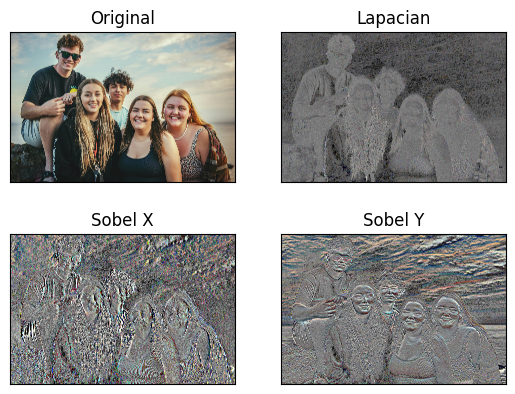

In [4]:
#laplacian and sobel
import cv2 as cv

image = cv.imread ('../assets/image1.jpg')
img = cv.cvtColor(image, cv.COLOR_BGR2RGB)

laplacian = cv.Laplacian(img, cv.CV_64F)
sobelX = cv.Sobel(img, cv.CV_64F, 1, 0, ksize = 5)
sobelY = cv.Sobel(img, cv.CV_64F, 0, 1, ksize = 5)

plt.subplot(2,2,1), plt.imshow(img, cmap="gray")
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,2), plt.imshow(laplacian, cmap="gray")
plt.title('Lapacian'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,3), plt.imshow(sobelX, cmap="gray")
plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,4), plt.imshow(sobelY, cmap="gray")
plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])


(Text(0.5, 1.0, 'Edge'), ([], []), ([], []))

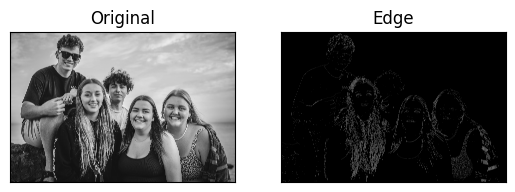

In [2]:
#Edge Detection
import cv2 as cv

path = '../assets/image1.jpg'
img = cv.imread(path, cv.IMREAD_GRAYSCALE)
from matplotlib import pyplot as plt
edges = cv.Canny(img, 100, 200)
plt.subplot(121), plt.imshow(img, cmap= 'gray')
plt.title('Original'),plt.xticks ([]), plt.yticks([]), 
plt.subplot(122), plt.imshow(edges, cmap= 'gray')
plt.title('Edge'), plt.xticks([]), plt.yticks([])